Implement K means Clusturing Algorithm

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [40]:
df = pd.read_csv("clustering.csv")
print(df.head())
df.describe()

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001003   Male     Yes          1      Graduate            No   
1  LP001005   Male     Yes          0      Graduate           Yes   
2  LP001006   Male     Yes          0  Not Graduate            No   
3  LP001008   Male      No          0      Graduate            No   
4  LP001013   Male     Yes          0  Not Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             4583             1508.0       128.0             360.0   
1             3000                0.0        66.0             360.0   
2             2583             2358.0       120.0             360.0   
3             6000                0.0       141.0             360.0   
4             2333             1516.0        95.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Rural           N  
1             1.0         Urban           Y  
2             1.0   

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [41]:
print("\nDataset shape:")
print(df.shape)



Dataset shape:
(381, 13)


In [31]:
# Select required features

X = df[["LoanAmount", "ApplicantIncome"]]

X.head()

,LoanAmount,ApplicantIncome
0,128.0,4583
1,66.0,3000
2,120.0,2583
3,141.0,6000
4,95.0,2333


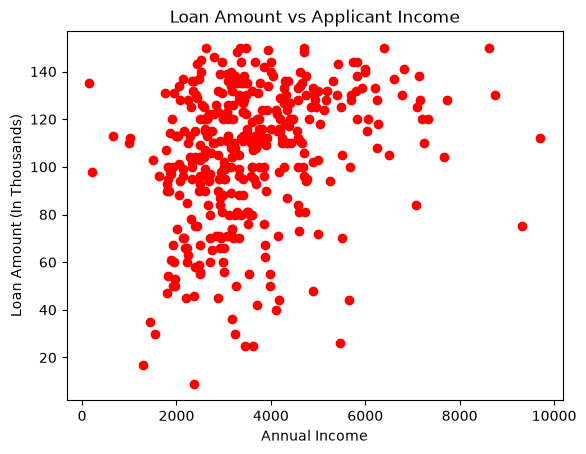

In [32]:
# Visualize data points

plt.scatter(
    X["ApplicantIncome"],
    X["LoanAmount"],
    c="red"
)

plt.xlabel("Annual Income")
plt.ylabel("Loan Amount (In Thousands)")
plt.title("Loan Amount vs Applicant Income")

plt.show()

In [33]:
# STEP 4: CHOOSE NUMBER OF CLUSTERS
K = 3

print("\nNumber of clusters:", K)

# Select random observations as initial centroids

Centroids = X.sample(n=K)

print(Centroids)


Number of clusters: 3
     LoanAmount  ApplicantIncome
118       120.0             1907
58         50.0             3988
307       131.0             1958


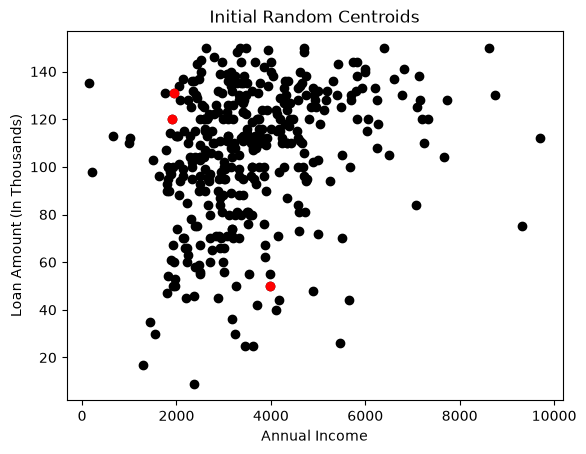

In [34]:
plt.scatter(
    X["ApplicantIncome"],
    X["LoanAmount"],
    c="black"
)

plt.scatter(
    Centroids["ApplicantIncome"],
    Centroids["LoanAmount"],
    c="red"
)

plt.xlabel("Annual Income")
plt.ylabel("Loan Amount (In Thousands)")
plt.title("Initial Random Centroids")

plt.show()

In [35]:
# Implement K-Means algorithm

diff = 1
j = 0

while diff != 0:

    XD = X.copy()

    i = 1

    # Calculate distance from every centroid
    for index1, row_c in Centroids.iterrows():

        ED = []

        for index2, row_d in XD.iterrows():

            d1 = (
                row_c["ApplicantIncome"]
                - row_d["ApplicantIncome"]
            ) ** 2

            d2 = (
                row_c["LoanAmount"]
                - row_d["LoanAmount"]
            ) ** 2

            d = np.sqrt(d1 + d2)

            ED.append(d)

        X[i] = ED

        i = i + 1

    # Assign each point to nearest centroid

    C = []

    for index, row in X.iterrows():

        min_dist = row[1]
        pos = 1

        for i in range(K):

            if row[i + 1] < min_dist:

                min_dist = row[i + 1]
                pos = i + 1

        C.append(pos)

    X["Cluster"] = C

    # Calculate new centroids

    Centroids_new = X.groupby(
        ["Cluster"]
    ).mean()[["LoanAmount", "ApplicantIncome"]]

    # Check convergence

    if j == 0:

        diff = 1
        j = j + 1

    else:

        diff = (
            Centroids_new["LoanAmount"]
            - Centroids["LoanAmount"]
        ).sum() + (
            Centroids_new["ApplicantIncome"]
            - Centroids["ApplicantIncome"]
        ).sum()

        print(diff)

    # Update centroids

    Centroids = X.groupby(
        ["Cluster"]
    ).mean()[["LoanAmount", "ApplicantIncome"]]

744.6600412338732
674.5500649929809
582.0351625033663
477.3086799567174
395.3683037751367
208.20701490075197
216.13679395380288
277.68763984371935
244.66095351174067
229.06905235705375
218.24897861156342
107.07928213052429
52.84741626127729
98.54724443834282
90.64953219227577
18.274686272279013
9.21023994083339
18.345487493007468
46.27013250786139
0.0


In [36]:
d = np.sqrt(d1 + d2)
X[i] = ED
print("\nFinal Centroids:")
print(Centroids)


Final Centroids:
         LoanAmount  ApplicantIncome
Cluster                             
1         97.472527      2497.972527
2        119.488372      6512.767442
3        109.756410      4033.596154


In [ ]:
if row[i + 1] < min_dist:
    X["Cluster"] = C
    Centroids_new = X.groupby(
    ["Cluster"]
).mean()[["LoanAmount", "ApplicantIncome"]]
print("\nFinal Centroids:")
print(Centroids_new)


Final Centroids:
         LoanAmount  ApplicantIncome
Cluster                             
1         97.472527      2497.972527
2        119.488372      6512.767442
3        109.756410      4033.596154
